# **Customer churn**

In [26]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression 
from sklearn import svm
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn import tree
import seaborn as sns
from sklearn import metrics
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    precision_score, 
    recall_score, 
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)

import matplotlib.pyplot as plt
from IPython.display import display

url = "https://raw.githubusercontent.com/alishermutalov/praktikum-datasets/refs/heads/praktikum/Churn_Modelling.xls"
df = pd.read_csv(url, index_col='RowNumber')
df

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
RowNumber,,,,,,,,,,,,,
1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1


# **Analysis**

In [27]:
# Javobni shu yerda yozing.
print(f"{df.shape}\n")
print(df.isna().sum())


(10000, 13)

CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 1 to 10000
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1.1+ MB


In [29]:
df.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [30]:
df['Geography'].value_counts()


,count
Geography,
France,5014
Germany,2509
Spain,2477


In [31]:
#encoder
encoder = LabelEncoder()
df['Geography'] = encoder.fit_transform(df['Geography'])
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
RowNumber,,,,,,,,,,,,,
1,15634602,Hargrave,619,0,Female,42,2,0.00,1,1,1,101348.88,1
2,15647311,Hill,608,2,Female,41,1,83807.86,1,0,1,112542.58,0
3,15619304,Onio,502,0,Female,42,8,159660.80,3,1,0,113931.57,1
4,15701354,Boni,699,0,Female,39,1,0.00,2,0,0,93826.63,0
5,15737888,Mitchell,850,2,Female,43,2,125510.82,1,1,1,79084.10,0


In [32]:
numeric_df = df.drop(['Surname', 'Gender', 'CustomerId'], axis=1)
numeric_df.corrwith(df['Exited']).abs().sort_values(ascending=False)


,0
Exited,1.000000
Age,0.285323
IsActiveMember,0.156128
Balance,0.118533
NumOfProducts,0.047820
Geography,0.035943
CreditScore,0.027094
Tenure,0.014001
EstimatedSalary,0.012097
HasCrCard,0.007138


In [33]:
df['Exited'].value_counts() / len(df)*100

,count
Exited,
0,79.63
1,20.37


In [34]:
df = df.dropna()

# **Visualisation**

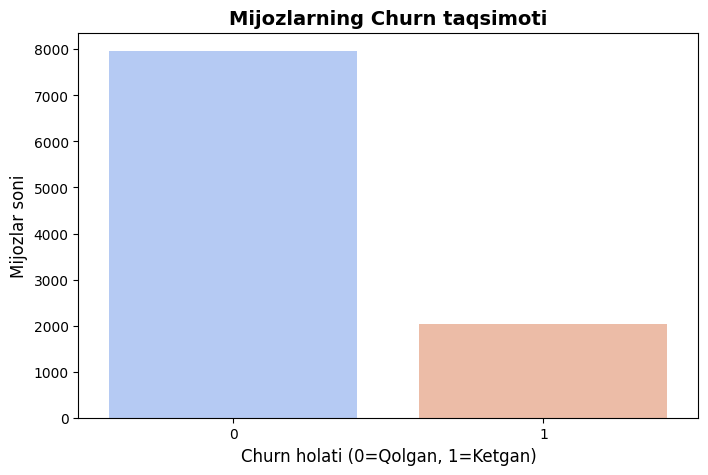

Bankda qolgan mijozlar: 7963 (79.63%)
Bankdan ketgan mijozlar: 2037 (20.37%)


In [35]:
# Maqsadli o'zgaruvchi taqsimoti
plt.figure(figsize=(8, 5))
sns.countplot(x='Exited', data=df, palette='coolwarm', hue='Exited', legend=False)
plt.title("Mijozlarning Churn taqsimoti", fontsize=14, fontweight='bold')
plt.xlabel("Churn holati (0=Qolgan, 1=Ketgan)", fontsize=12)
plt.ylabel("Mijozlar soni", fontsize=12)
plt.show()

# Churn yuzdagi ma'lumot
exited_counts = df['Exited'].value_counts()
exited_pct = (df['Exited'].value_counts() / len(df) * 100).round(2)
print(f"Bankda qolgan mijozlar: {exited_counts[0]} ({exited_pct[0]}%)")
print(f"Bankdan ketgan mijozlar: {exited_counts[1]} ({exited_pct[1]}%)")

/tmp/ipykernel_2670/1574740913.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='Age', data=df, palette='Set2', ax=axes[0])
/tmp/ipykernel_2670/1574740913.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='Balance', data=df, palette='Set2', ax=axes[1])


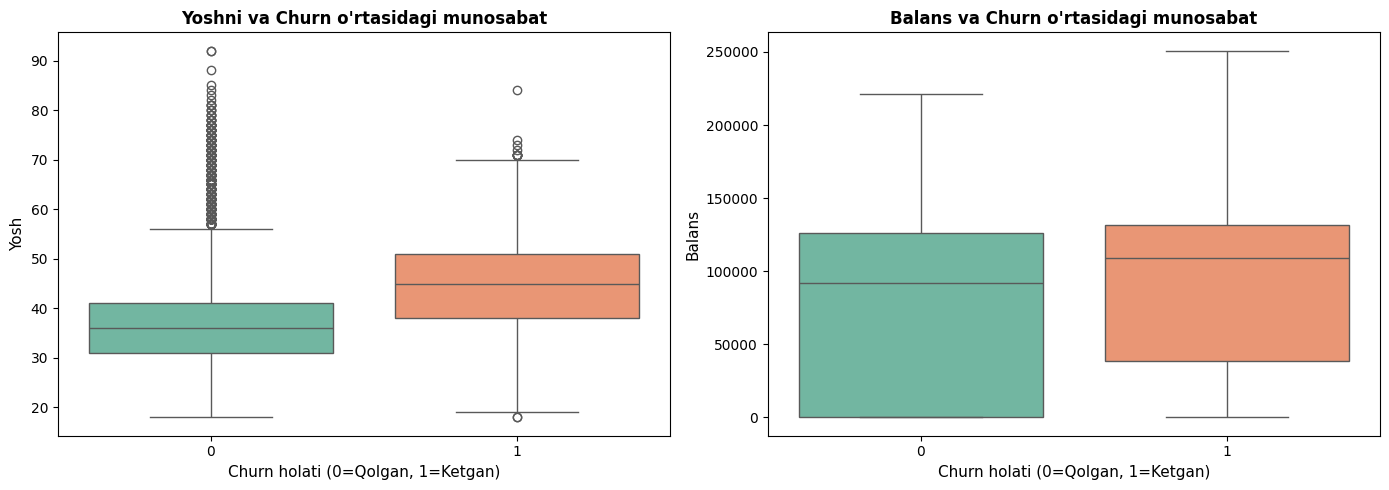

In [36]:
# Age va Balance ni Exited o'zgaruvchi bilan taqqoslash
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age vs Exited
sns.boxplot(x='Exited', y='Age', data=df, palette='Set2', ax=axes[0])
axes[0].set_title("Yoshni va Churn o'rtasidagi munosabat", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Churn holati (0=Qolgan, 1=Ketgan)", fontsize=11)
axes[0].set_ylabel("Yosh", fontsize=11)

# Balance vs Exited
sns.boxplot(x='Exited', y='Balance', data=df, palette='Set2', ax=axes[1])
axes[1].set_title("Balans va Churn o'rtasidagi munosabat", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Churn holati (0=Qolgan, 1=Ketgan)", fontsize=11)
axes[1].set_ylabel("Balans", fontsize=11)

plt.tight_layout()
plt.show()


In [37]:
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
RowNumber,,,,,,,,,,,,,
1,15634602,Hargrave,619,0,Female,42,2,0.00,1,1,1,101348.88,1
2,15647311,Hill,608,2,Female,41,1,83807.86,1,0,1,112542.58,0
3,15619304,Onio,502,0,Female,42,8,159660.80,3,1,0,113931.57,1
4,15701354,Boni,699,0,Female,39,1,0.00,2,0,0,93826.63,0
5,15737888,Mitchell,850,2,Female,43,2,125510.82,1,1,1,79084.10,0


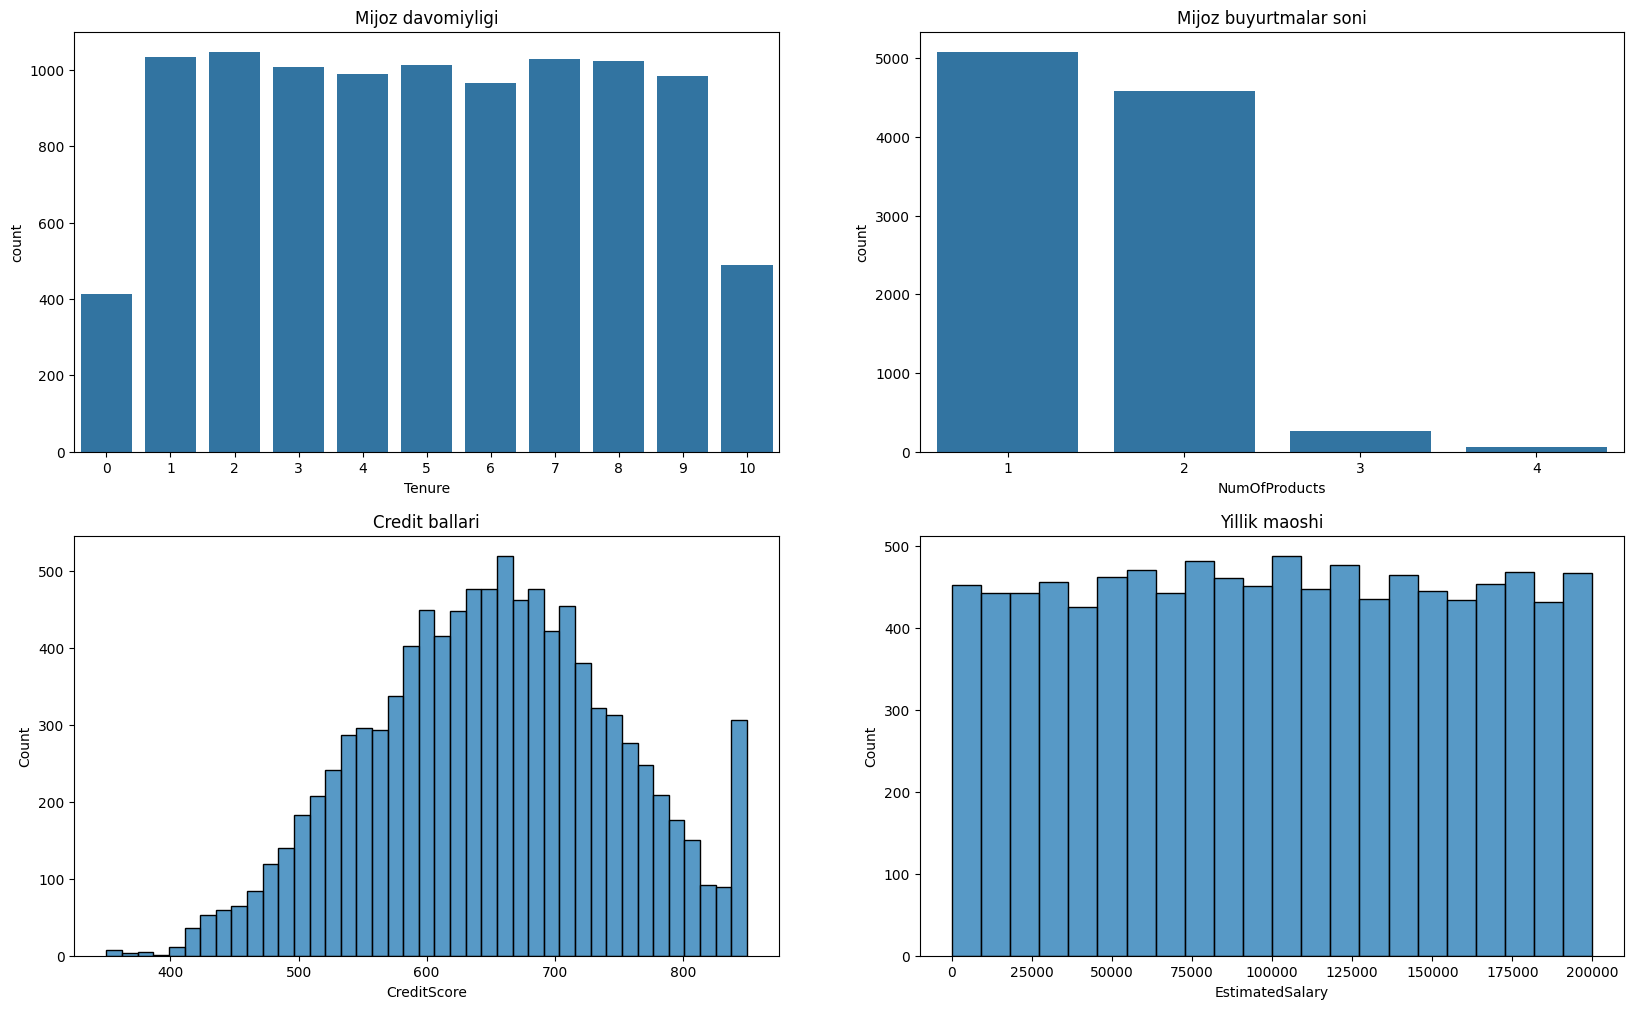

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(20,12))

#Tenure
sns.countplot(x="Tenure", data=df, ax=axes[0,0])
axes[0,0].set_title("Mijoz davomiyligi")

#NumOfProducts
sns.countplot(x="NumOfProducts", data=df, ax=axes[0,1])
axes[0,1].set_title("Mijoz buyurtmalar soni")

#CreditScore
sns.histplot(x="CreditScore", data=df, ax=axes[1,0])
axes[1,0].set_title("Credit ballari")

#EstimatedSalary
sns.histplot(x="EstimatedSalary", data=df, ax=axes[1,1])
axes[1,1].set_title("Yillik maoshi")

# axes[1,1].axis("off")
plt.show()

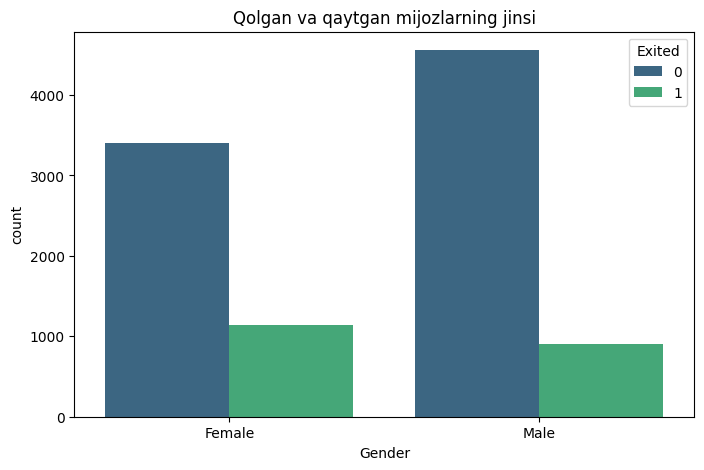

In [39]:
plt.figure(figsize=(8,5))

sns.countplot(x='Gender', hue="Exited", palette="viridis", data=df)
plt.title("Qolgan va qaytgan mijozlarning jinsi")
plt.show()

# **Preparation to ML**

In [40]:
df.drop(["Surname", "CustomerId"], axis=1, inplace=True) # Exclude irrelevant features from prediction

df['Gender'] = LabelEncoder().fit_transform(df['Gender']) # Convert Gender into numbers

In [41]:
x = df.drop("Exited", axis=1)
y = df['Exited']

In [42]:
x = StandardScaler().fit_transform(x)

In [43]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

# **ML**

**Logistic Regression**

In [44]:
lr_model = LogisticRegression()
lr_model.fit(x_train, y_train)
y_pred = lr_model.predict(x_test)

Accuracy:  0.8050
Precision: 0.5859
Recall:    0.1425
F1-Score:  0.2292


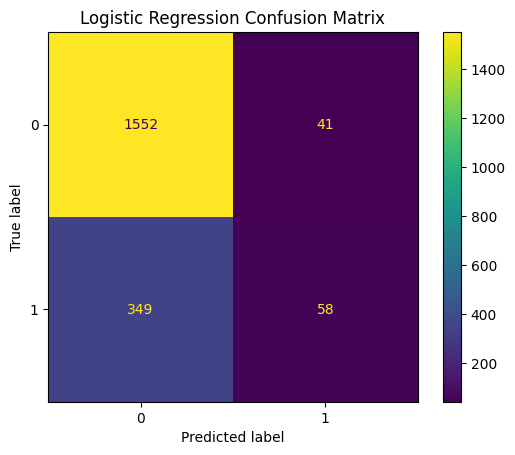

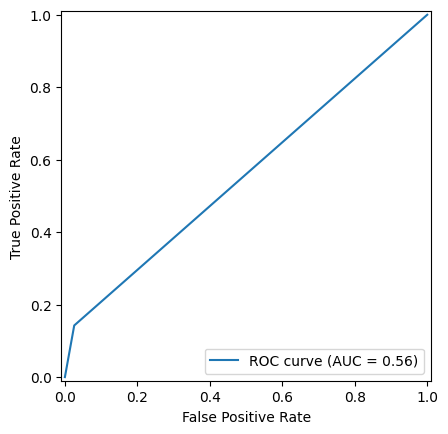

In [45]:
# testing
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

#Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

#Roc curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='ROC curve')
display.plot()
plt.show()


**Support Vector machine**

Accuracy:  0.8560
Precision: 0.8362
Recall:    0.3636
F1-Score:  0.5068


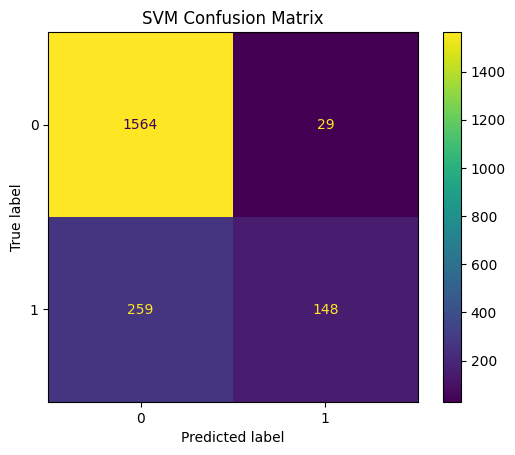

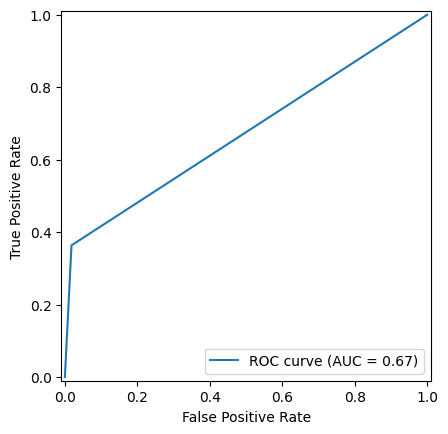

In [46]:
svm_model = SVC()
svm_model.fit(x_train, y_train)
y_pred = svm_model.predict(x_test)

# testing
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

#Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("SVM Confusion Matrix")
plt.show()

#Roc curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='ROC curve')
display.plot()
plt.show()

**Decision Tree**

Accuracy:  0.8540
Precision: 0.8042
Recall:    0.3735
F1-Score:  0.5101


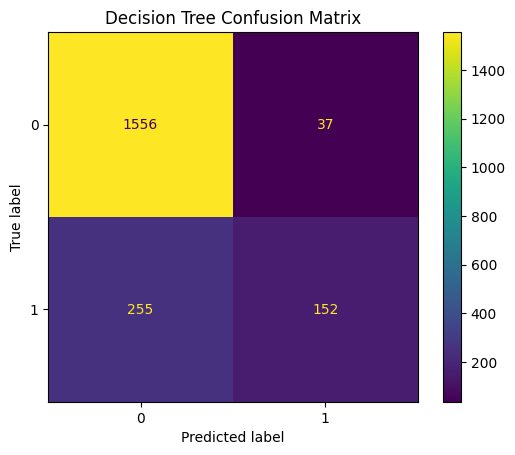

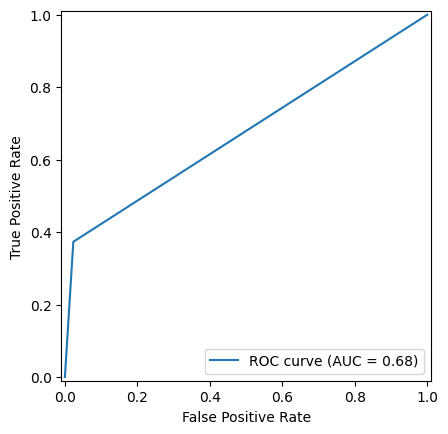

In [47]:
dec_model = DecisionTreeClassifier(max_depth=5, min_samples_split=10, min_samples_leaf=5, random_state=42) # Initialize Decision Tree with parameters to prevent overfitting
dec_model.fit(x_train, y_train) # Train the model
y_pred = dec_model.predict(x_test) # Predict the outcomes

# testing
accuracy = accuracy_score(y_test, y_pred) # Calculate accuracy
precision = precision_score(y_test, y_pred) # Calculate precision
recall = recall_score(y_test, y_pred) # Calculate recall
f1 = f1_score(y_test, y_pred) # Calculate F1-Score

print(f"Accuracy:  {accuracy:.4f}") # Print accuracy
print(f"Precision: {precision:.4f}") # Print precision
print(f"Recall:    {recall:.4f}") # Print recall
print(f"F1-Score:  {f1:.4f}") # Print F1 score

#Confusion matrix
cm = confusion_matrix(y_test, y_pred) # Generate confusion matrix
disp = ConfusionMatrixDisplay(cm) # Prepare display for confusion matrix
disp.plot() # Plot the matrix
plt.title("Decision Tree Confusion Matrix") # Add title
plt.show() # Show the plot

#Roc curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred) # Calculate ROC metrics
roc_auc = metrics.auc(fpr, tpr) # Calculate AUC
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='ROC curve') # Prepare ROC display
display.plot() # Plot the ROC curve
plt.show() # Show the curve

**Random Forest**

Accuracy:  0.8640
Precision: 0.8392
Recall:    0.4103
F1-Score:  0.5512


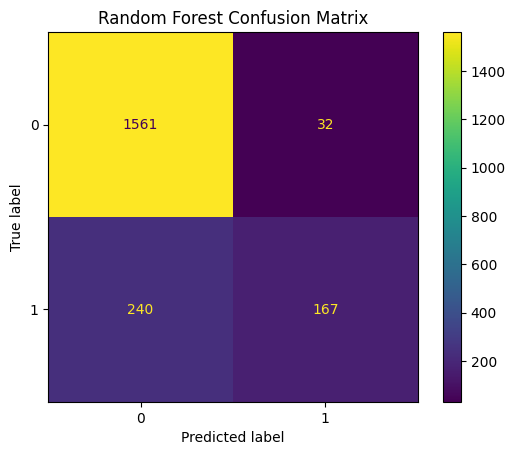

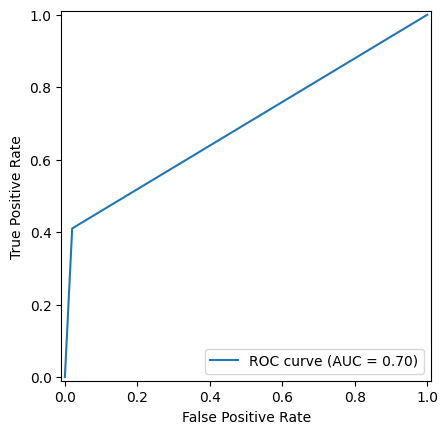

In [48]:
ran_model = RandomForestClassifier(n_estimators=100, max_depth=6, min_samples_split=10, min_samples_leaf=5, max_features='sqrt', random_state=42) # Initialize Random Forest with regularization against overfitting
ran_model.fit(x_train, y_train) # Train the model
y_pred = ran_model.predict(x_test) # Predict the outcomes

# testing
accuracy = accuracy_score(y_test, y_pred) # Calculate accuracy
precision = precision_score(y_test, y_pred) # Calculate precision
recall = recall_score(y_test, y_pred) # Calculate recall
f1 = f1_score(y_test, y_pred) # Calculate F1-Score

print(f"Accuracy:  {accuracy:.4f}") # Print accuracy
print(f"Precision: {precision:.4f}") # Print precision
print(f"Recall:    {recall:.4f}") # Print recall
print(f"F1-Score:  {f1:.4f}") # Print F1 score

#Confusion matrix
cm = confusion_matrix(y_test, y_pred) # Generate confusion matrix
disp = ConfusionMatrixDisplay(cm) # Prepare display for confusion matrix
disp.plot() # Plot the matrix
plt.title("Random Forest Confusion Matrix") # Add title
plt.show() # Show the plot

#Roc curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred) # Calculate ROC metrics
roc_auc = metrics.auc(fpr, tpr) # Calculate AUC
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='ROC curve') # Prepare ROC display
display.plot() # Plot the ROC curve
plt.show() # Show the curve

**XGboost**

Accuracy:  0.8685
Precision: 0.8186
Recall:    0.4545
F1-Score:  0.5845


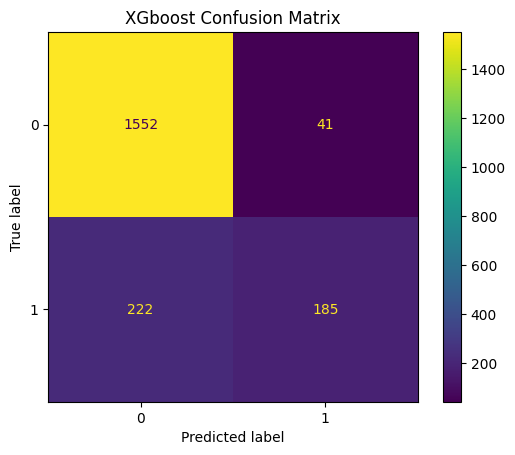

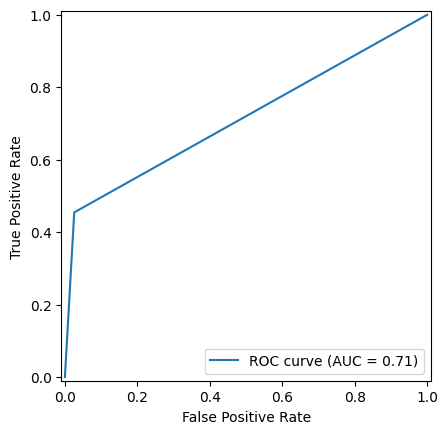

In [49]:
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8, gamma=1, random_state=42, eval_metric='logloss') # Initialize XGBoost with optimized parameters to counter overfitting
xgb_model.fit(x_train, y_train) # Train the model
y_pred = xgb_model.predict(x_test) # Predict the outcomes

# testing
accuracy = accuracy_score(y_test, y_pred) # Calculate accuracy
precision = precision_score(y_test, y_pred) # Calculate precision
recall = recall_score(y_test, y_pred) # Calculate recall
f1 = f1_score(y_test, y_pred) # Calculate F1-Score

print(f"Accuracy:  {accuracy:.4f}") # Print accuracy
print(f"Precision: {precision:.4f}") # Print precision
print(f"Recall:    {recall:.4f}") # Print recall
print(f"F1-Score:  {f1:.4f}") # Print F1 score

#Confusion matrix
cm = confusion_matrix(y_test, y_pred) # Generate confusion matrix
disp = ConfusionMatrixDisplay(cm) # Prepare display for confusion matrix
disp.plot() # Plot the matrix
plt.title("XGboost Confusion Matrix") # Add title
plt.show() # Show the plot

#Roc curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred) # Calculate ROC metrics
roc_auc = metrics.auc(fpr, tpr) # Calculate AUC
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='ROC curve') # Prepare ROC display
display.plot() # Plot the ROC curve
plt.show() # Show the curve

# **Model Comparision**

Model comparison table:


,Model,Accuracy,Precision,Recall,F1-Score
0,XGBoost,0.8685,0.8186,0.4545,0.5845
1,Random Forest,0.8640,0.8392,0.4103,0.5512
2,Decision Tree,0.8540,0.8042,0.3735,0.5101
3,SVM,0.8560,0.8362,0.3636,0.5068
4,Logistic Regression,0.8050,0.5859,0.1425,0.2292


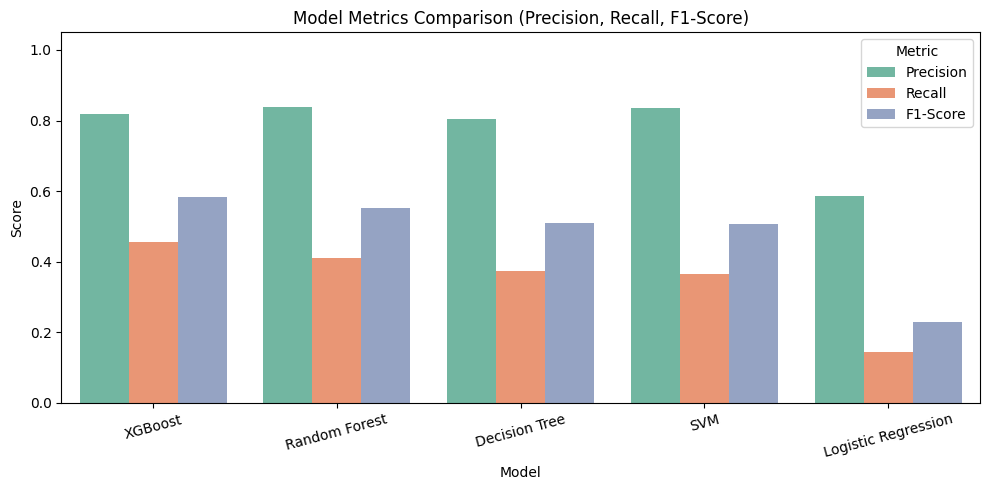

Best model: XGBoost


In [50]:
from IPython.display import display as ipy_display

models = {
    'Logistic Regression': lr_model,
    'Decision Tree': dec_model,
    'Random Forest': ran_model,
    'SVM': svm_model,
    'XGBoost': xgb_model
}

results = []
for model_name, model in models.items():
    y_pred = model.predict(x_test)
    results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
    })

results_df = pd.DataFrame(results).sort_values(
    by=['F1-Score', 'Accuracy', 'Precision', 'Recall'],
    ascending=False
).reset_index(drop=True)

print('Model comparison table:')
ipy_display(results_df.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-Score': '{:.4f}'
}))

plt.figure(figsize=(10, 5))
melted = results_df.melt(id_vars='Model', value_vars=['Precision', 'Recall', 'F1-Score'])
sns.barplot(data=melted, x='Model', y='value', hue='variable', palette='Set2')
plt.title('Model Metrics Comparison (Precision, Recall, F1-Score)')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0.0, 1.05)
plt.xticks(rotation=15)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

best_model = results_df.iloc[0]
print(f"Best model: {best_model['Model']}")